In [26]:
import sys

import cloudpickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.special import softmax
from sklearn.preprocessing import LabelEncoder
import torch

from sc_exp_design.constants import ParamsFields
from sc_exp_design.models import FlowMatching, TargetPredictionModel

In [11]:
sys.path.insert(0, "../inverse_utils")
sys.path.insert(0, f"../../model_utils")
from z_norm_modules import ZNorm, IZNorm, RescaledTargetPredictionModel


In [14]:
posterior_results_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/posterior_results.pkl"
fwd_query_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/posterior_fwd_queries.pkl"
model_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/dumps/2025-12-14_11-53-04/cerulean-durian-19_FlowMatching.pkl"
classifier_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/dumps/2025-11-14_21-22-45/dashing-frog-1258_TargetPredictionModel.pkl"

In [3]:
with open(posterior_results_path, "rb") as fb:
    posterior_results = cloudpickle.load(fb)

In [4]:
with open(fwd_query_path, "rb") as fb:
    fwd_results = cloudpickle.load(fb)

In [7]:
flow_matching = FlowMatching.load(model_path)
flow_matching

In [12]:
X_channel_params_inv = flow_matching.train_data.adata.uns["X_channel_params"]
X_scatter_params_inv = flow_matching.train_data.adata.uns["X_scatter_params"]
params_inv = {
    ParamsFields.MEAN: torch.from_numpy(
        np.concatenate(
            (
                X_channel_params_inv[ParamsFields.MEAN],
                X_scatter_params_inv[ParamsFields.MEAN]
            ), axis=0
        )
    ),
    ParamsFields.COVARIANCE: torch.from_numpy(
        np.concatenate(
            (
                X_channel_params_inv["std"],
                X_scatter_params_inv["std"]
            ), axis=0
        )
    ),
}
izn = IZNorm(params_inv)
izn

IZNorm(
  (params): ModuleDict(
    (mean): ModelParam()
    (covariance): ModelParam()
  )
)

(<Figure size 300x300 with 1 Axes>, <Axes: title={'center': 'loss'}>)

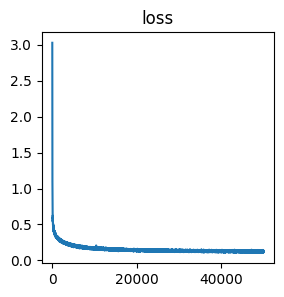

In [16]:
target_prediction_model = TargetPredictionModel.load(
    classifier_path
)
ct_le = LabelEncoder().fit(target_prediction_model.train_data.adata.obs["cell_type"].values)
target_prediction_model.target_predictor_trainer.plot_training_logs()

In [17]:
X_channel_params_fwd = target_prediction_model.train_data.adata.uns["X_channel_params"]
X_scatter_params_fwd = target_prediction_model.train_data.adata.uns["X_scatter_params"]
print(f"{X_channel_params_fwd.keys()}, {X_scatter_params_fwd.keys()}")
params_fwd = {
    ParamsFields.MEAN: torch.from_numpy(
        np.concatenate(
            (
                X_channel_params_fwd[ParamsFields.MEAN],
                X_scatter_params_fwd[ParamsFields.MEAN]
            ), axis=0
        )
    ),
    ParamsFields.COVARIANCE: torch.from_numpy(
        np.concatenate(
            (
                X_channel_params_fwd["std"],
                X_scatter_params_fwd["std"]
            ), axis=0
        )
    ),
}
zn = ZNorm(params_fwd)
zn

dict_keys(['mean', 'std']), dict_keys(['mean', 'std'])


ZNorm(
  (params): ModuleDict(
    (mean): ModelParam()
    (covariance): ModelParam()
  )
)

In [18]:
g_model = RescaledTargetPredictionModel(
    target_prediction_model.target_prediction_model,
    inv_params=izn,
    fwd_params=zn
)
le_ct = LabelEncoder().fit(target_prediction_model.train_data.adata.obs["cell_type"])

In [8]:
n_train_cells = 75_000
n_val_cells = 25_000
train_adata_fwd = sc.pp.sample(
    flow_matching.train_data.adata,
    n=n_train_cells,
    copy=True
)
val_adata_fwd = sc.pp.sample(
    next(iter(flow_matching.validation_data.values())).adata,
    n=n_val_cells,
    copy=True
)
print(f"{train_adata_fwd=}, {val_adata_fwd=}")

train_adata_fwd=AnnData object with n_obs × n_vars = 75000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'protocol_id'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps', 'one_hot', '740-yp_[µm]_one_hot', 'mtg_[µm]_one_hot', 'rhflt3l_[ng_ml]_one_hot', 'gm-csf_[ng_ml]_one_hot', 'tpo_[ng_ml]_one

In [21]:
cell_state_rep = "X_channel_standardized+X_scatter_standardized"
perturbation_reps = "condition_concat"

X_train = train_adata_fwd.obsm[cell_state_rep]
X_val = val_adata_fwd.obsm[cell_state_rep]
g_model.eval()
with torch.no_grad():
    G_logits_train = g_model(
        torch.from_numpy(X_train).float().to("cuda")
    )["cell_type"].detach().cpu().numpy()
    G_logits_val = g_model(
        torch.from_numpy(X_val).float().to("cuda")
    )["cell_type"].detach().cpu().numpy()
G_probs_train = softmax(G_logits_train, axis=1)
G_probs_val = softmax(G_logits_val, axis=1)
G_id_train = G_probs_train.argmax(1)
G_id_val = G_probs_val.argmax(1)
G_label_train = ct_le.inverse_transform(G_id_train)
G_label_val = ct_le.inverse_transform(G_id_val)
target_probs = G_probs_val.mean(0)
print(f"{G_logits_train.shape=}, {G_logits_val.shape=}, {G_probs_train.shape=}, {G_probs_val.shape=}, {G_id_train.shape=}, {G_id_val.shape=}, {G_label_train.shape=}, {G_label_val.shape=}")

G_logits_train.shape=(75000, 19), G_logits_val.shape=(25000, 19), G_probs_train.shape=(75000, 19), G_probs_val.shape=(25000, 19), G_id_train.shape=(75000,), G_id_val.shape=(25000,), G_label_train.shape=(75000,), G_label_val.shape=(25000,)


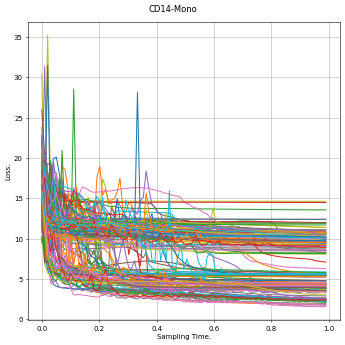

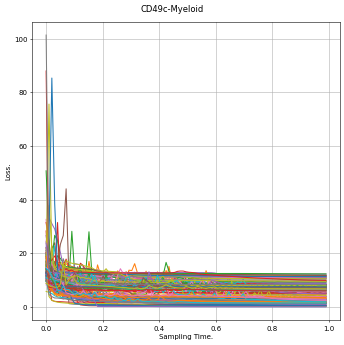

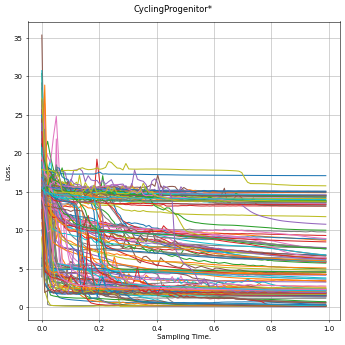

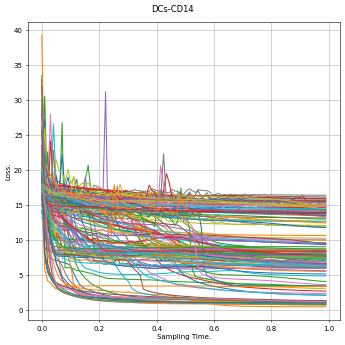

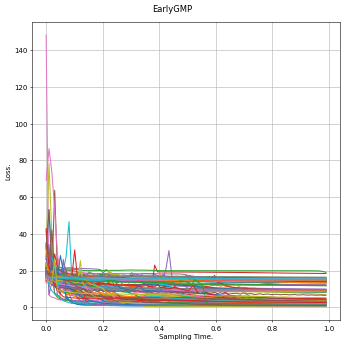

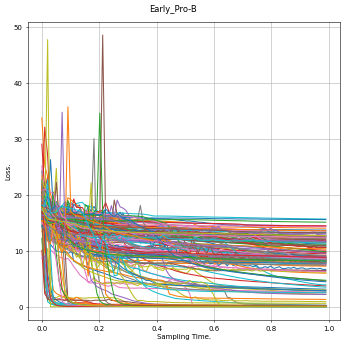

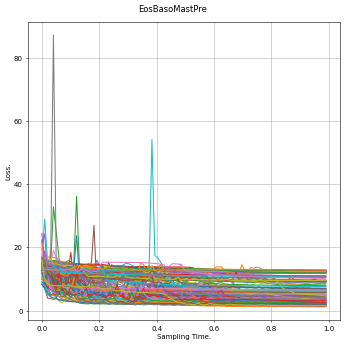

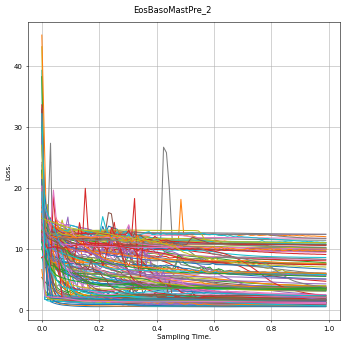

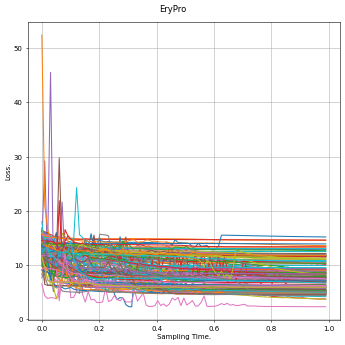

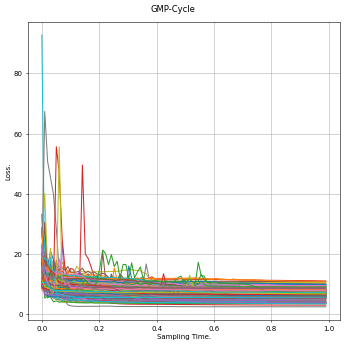

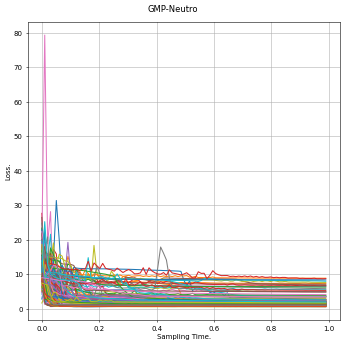

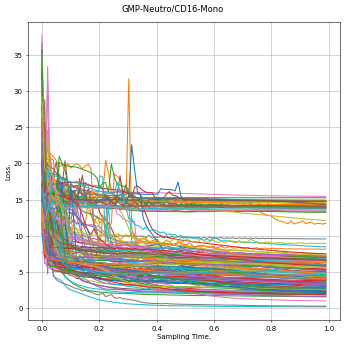

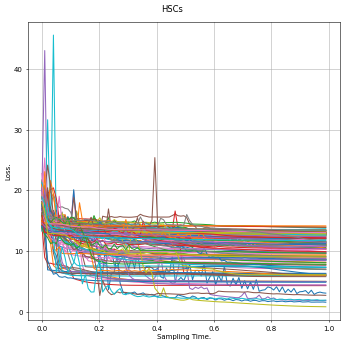

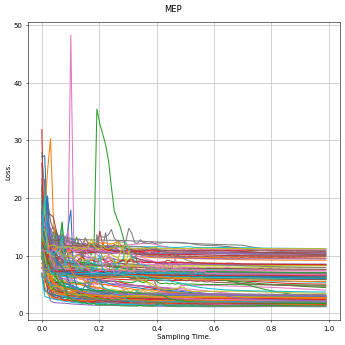

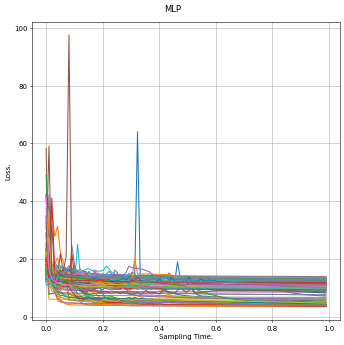

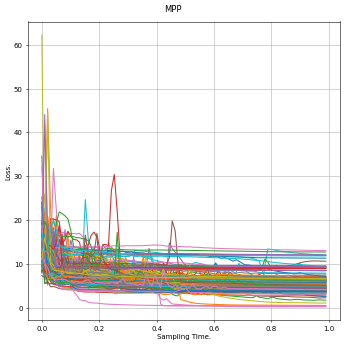

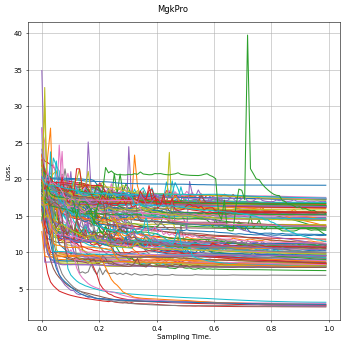

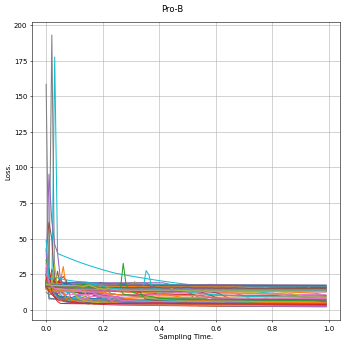

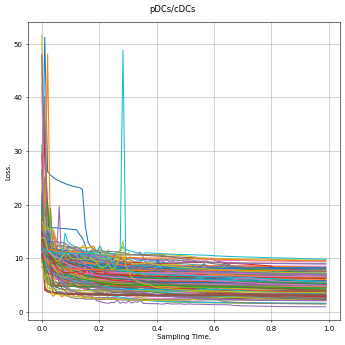

In [25]:
for ct, res_dict in posterior_results.items():
    loss_history = res_dict["loss_history"]
    fig, ax = plt.subplots(figsize=(7, 7), dpi=50)
    t = np.arange(0, 1, 1/loss_history.shape[1])
    lines = ax.plot(t, loss_history.T)
    fig.suptitle(f"{ct}")
    ax.set_xlabel("Sampling Time.")
    ax.set_ylabel("Loss.")
    ax.grid(1)
    fig.tight_layout(); fig.show()
    safe_ct = ct.replace("/", "_")

In [27]:
n_scatter_feats = 6
adatas_dict = {}
for ct, preds_dict in fwd_results.items():
    print(ct)
    loss_history = posterior_results[ct]["loss_history"]
    emin_loss_idx = np.argmin(loss_history[:, -1])
    X = np.concatenate((preds_dict["X"][emin_loss_idx],
        train_adata_fwd.obsm[cell_state_rep],
        val_adata_fwd.obsm[cell_state_rep]), axis=0)
    g_model.eval()
    with torch.no_grad():
        g_logits = g_model(torch.from_numpy(X).cuda())["cell_type"].detach().cpu().numpy()
    g_probs = softmax(g_logits, axis=-1)
    g_label = ct_le.inverse_transform(g_probs.argmax(1))
    X_channel = X[:, :-n_scatter_feats]
    X_scatter = X[:, -n_scatter_feats:]
    ct_adata = sc.AnnData(
        X=X_channel,
        obsm={"X_scatter": X_scatter},
        obs={
            "cell_type": g_label,
            "data_type": ["gen"]*preds_dict["X"][emin_loss_idx].shape[0] + \
                ["train"]*len(train_adata_fwd) + ["val"]*len(val_adata_fwd)
        },
        var=pd.DataFrame(index=train_adata_fwd.var_names)
    )
    sc.pp.pca(ct_adata)
    sc.pp.neighbors(ct_adata)
    sc.tl.umap(ct_adata)
    adatas_dict[ct] = ct_adata


CD14-Mono


/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


CD49c-Myeloid
CyclingProgenitor*
DCs-CD14
EarlyGMP
Early_Pro-B
EosBasoMastPre
EosBasoMastPre_2
EryPro
GMP-Cycle
GMP-Neutro
GMP-Neutro/CD16-Mono
HSCs
MEP
MLP
MPP
MgkPro
Pro-B
pDCs/cDCs


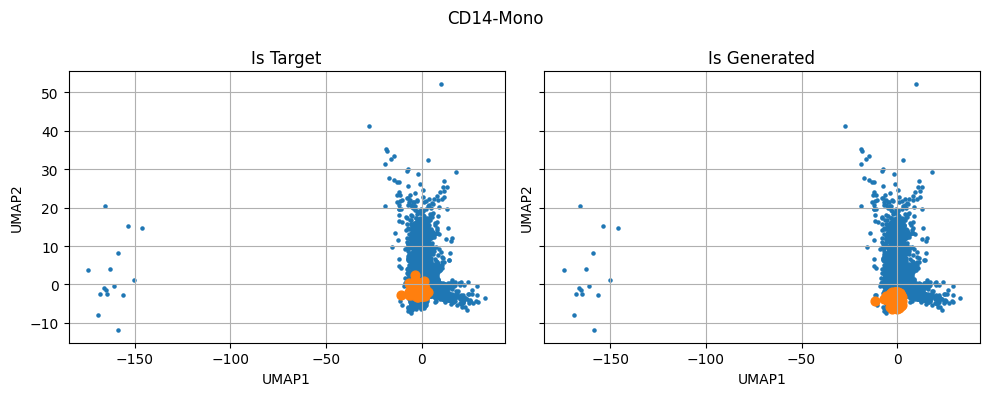

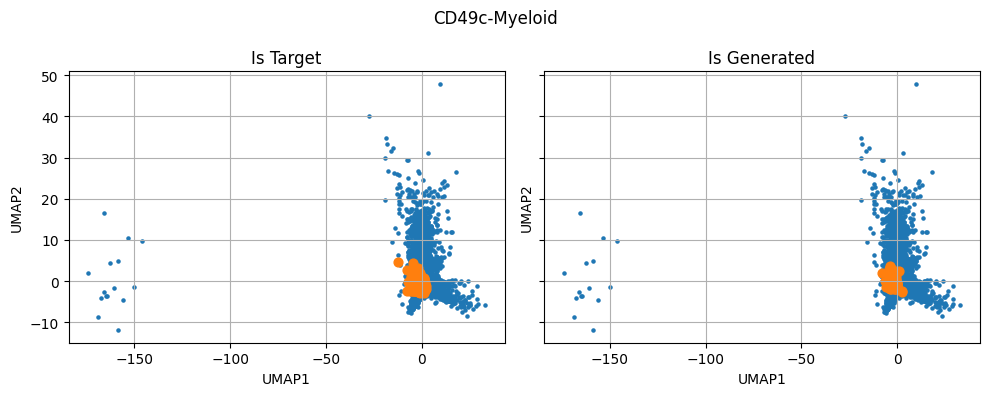

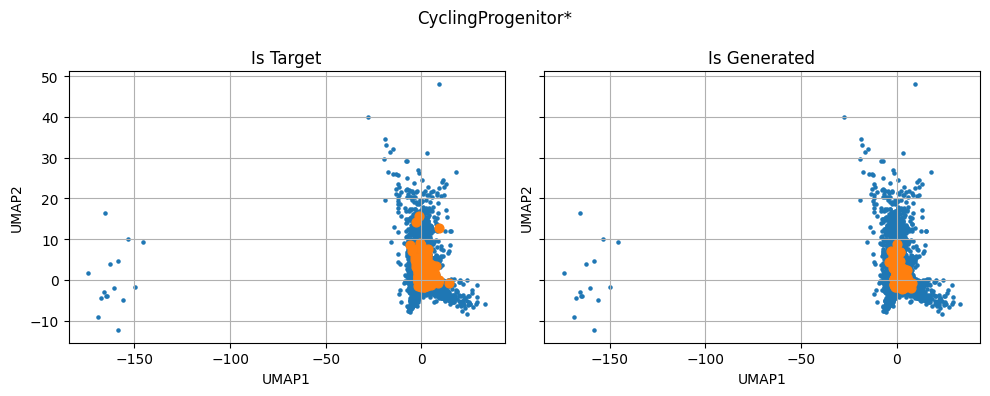

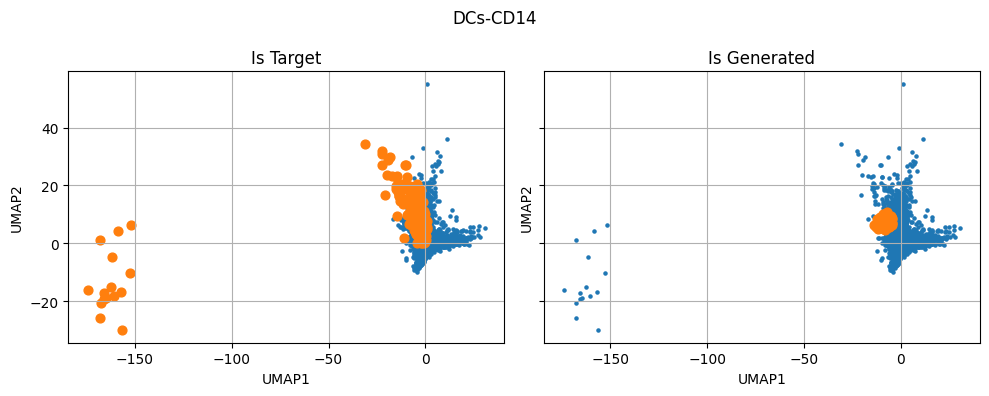

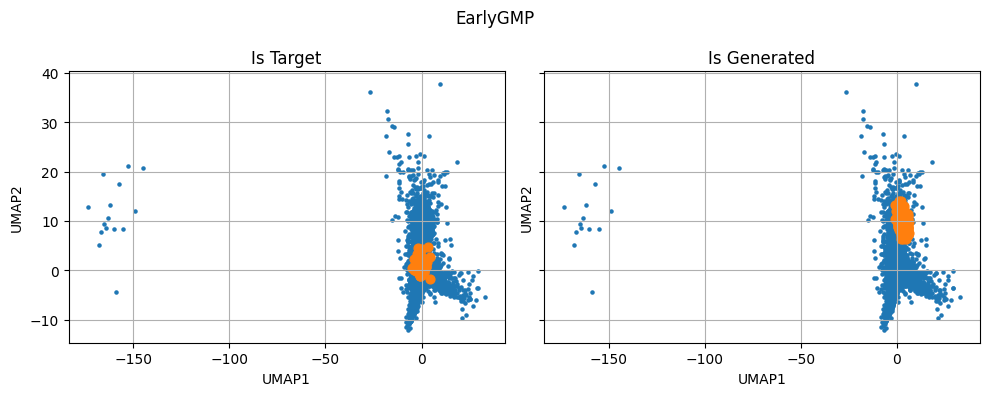

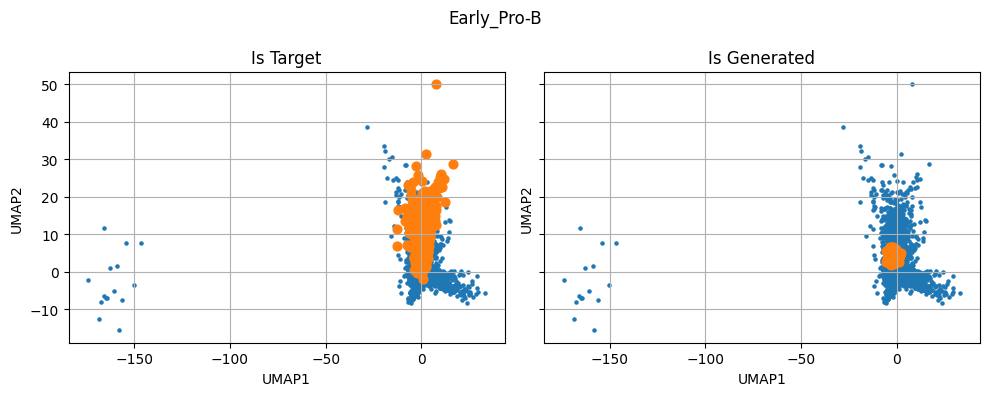

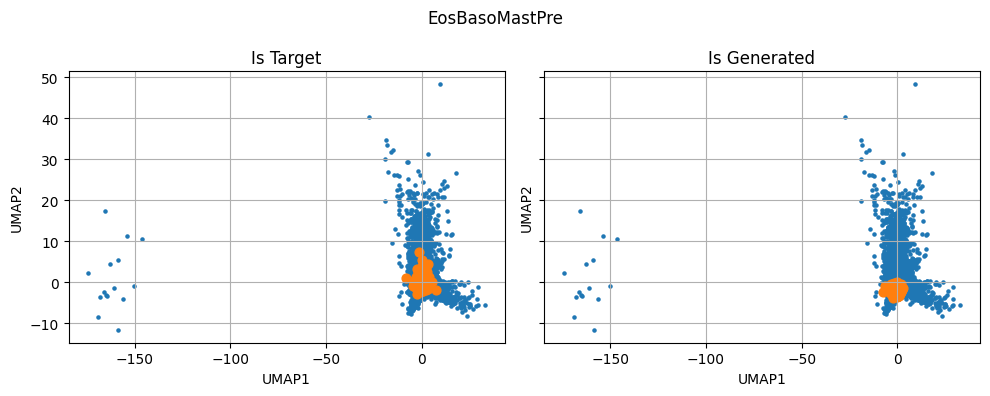

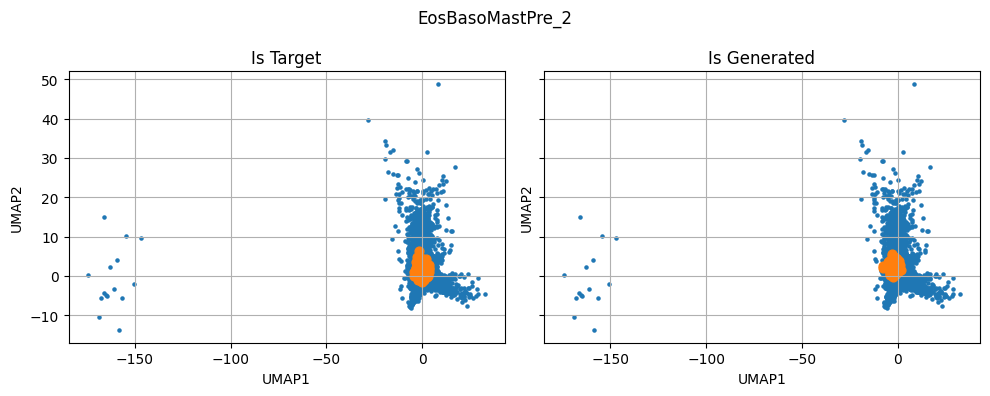

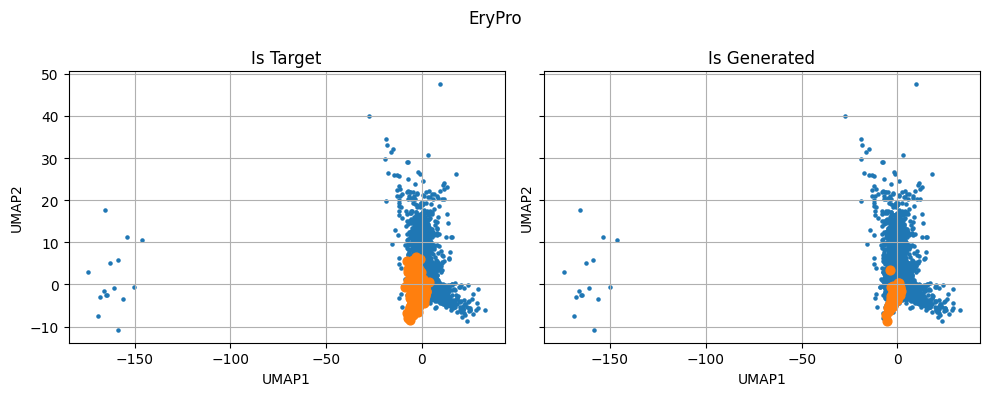

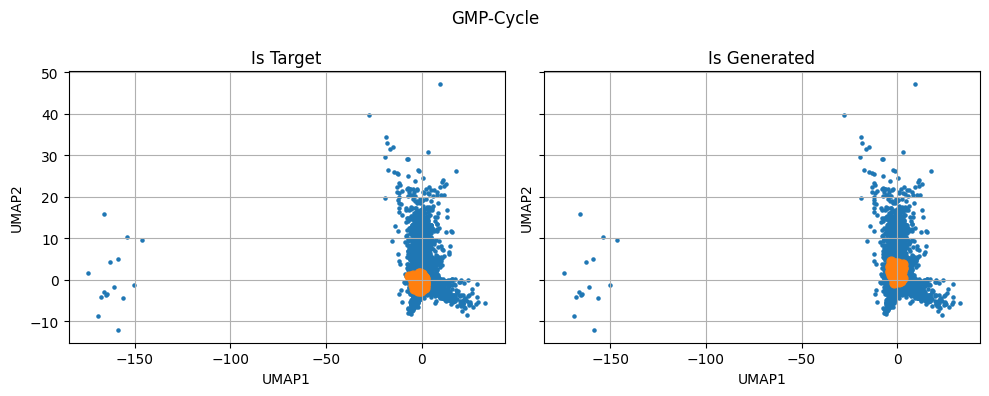

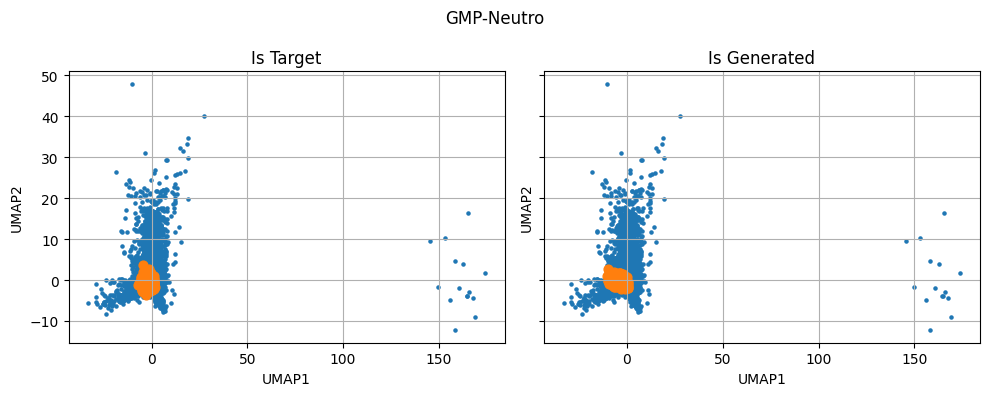

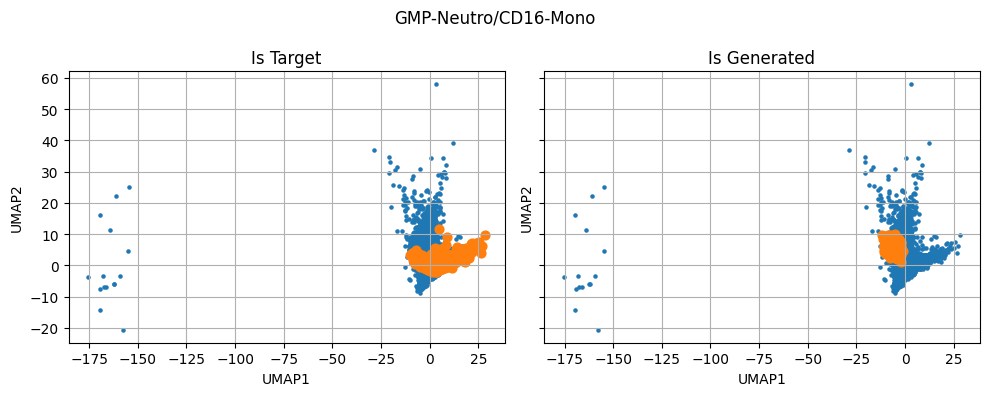

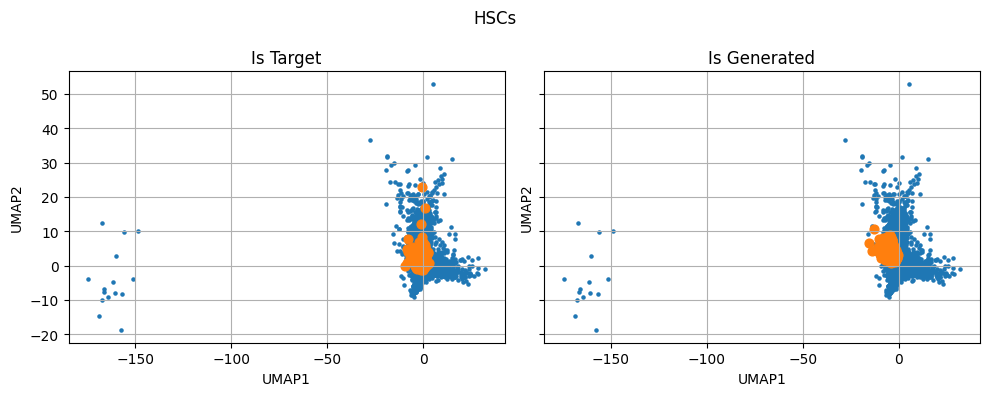

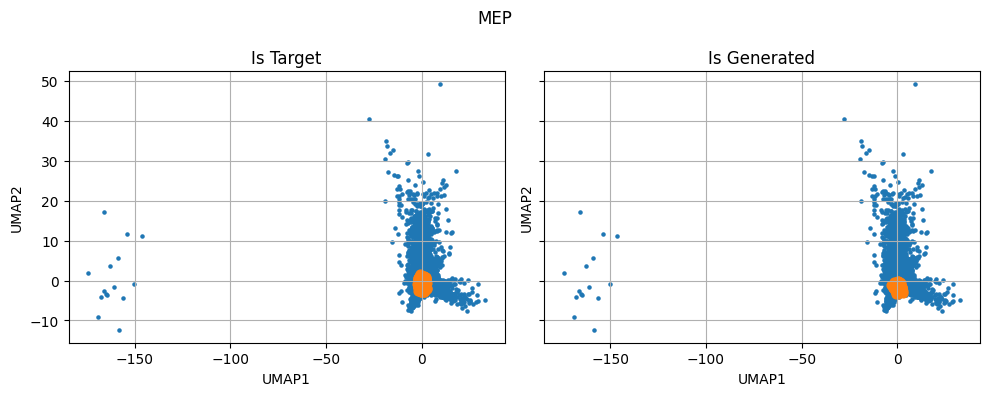

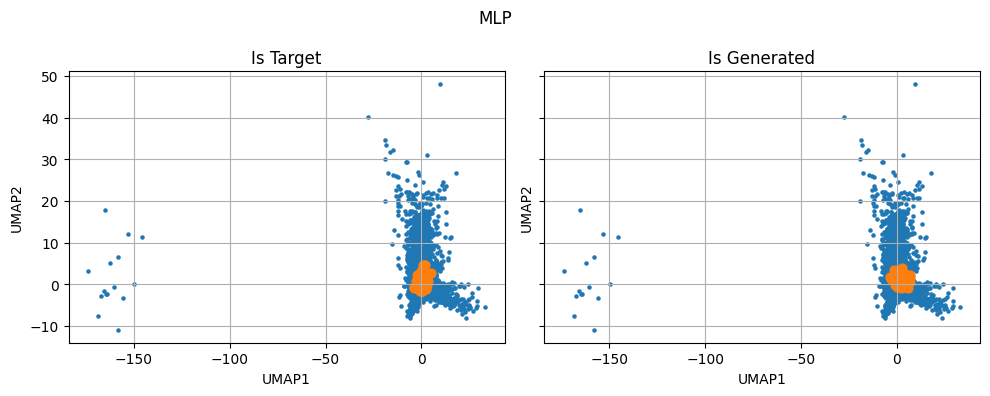

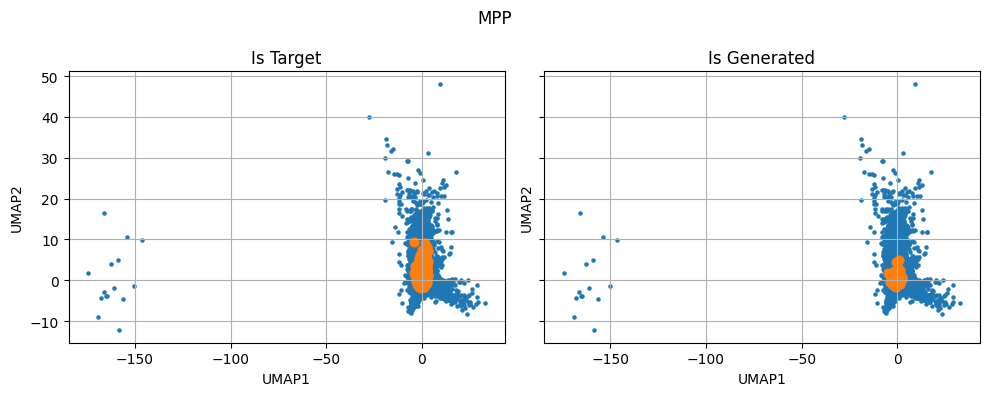

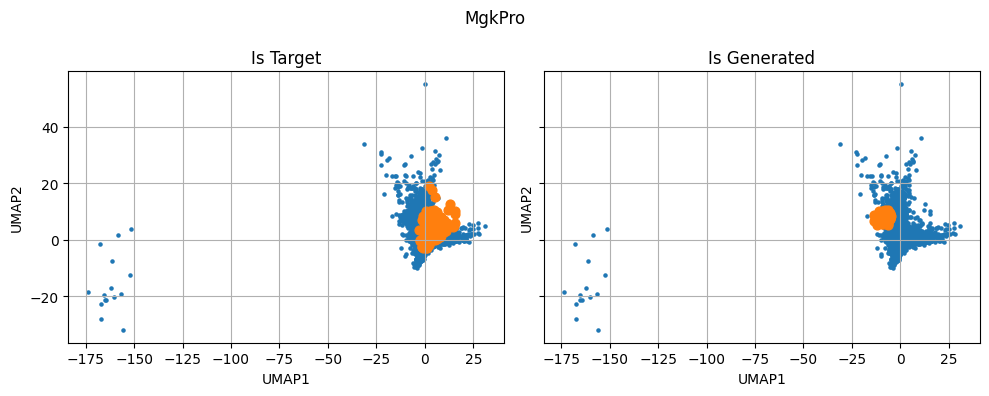

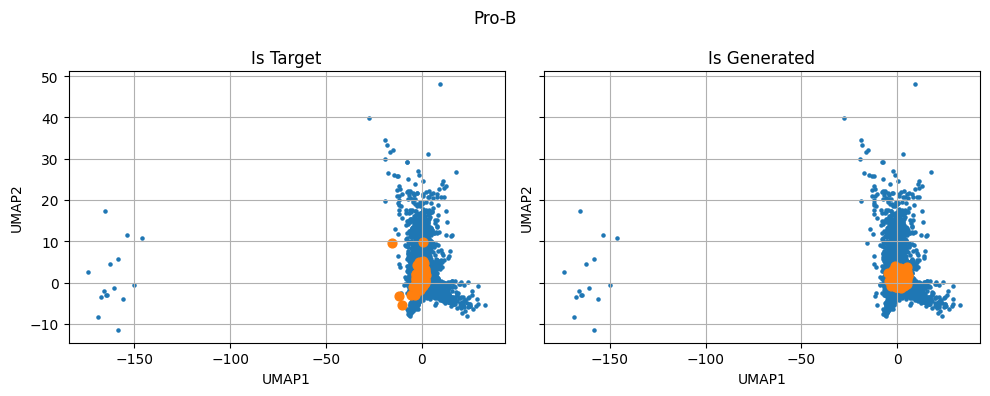

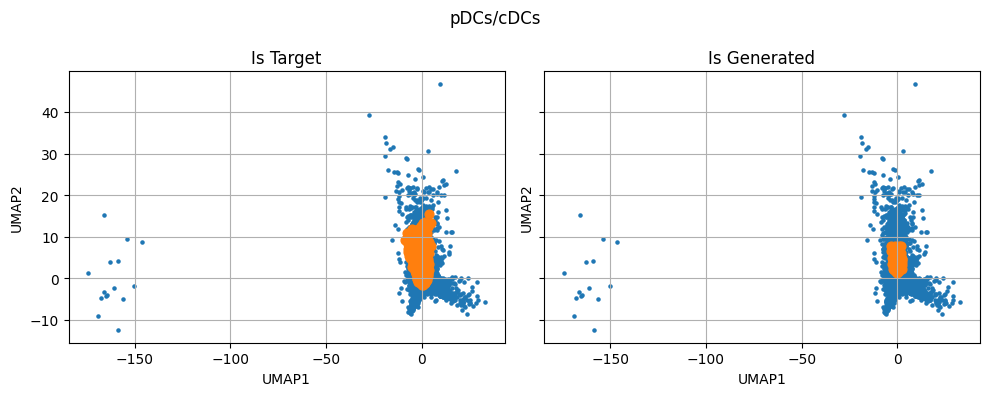

In [33]:
for ct, ct_adata in adatas_dict.items():
    # X_umap = ct_adata.obsm["X_umap"]
    X_umap = ct_adata.obsm["X_pca"]
    ct_mask = (ct_adata.obs["cell_type"] == ct) & (ct_adata.obs["data_type"] != "gen")
    gen_mask = ct_adata.obs["data_type"] == "gen"
    fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
    fig.suptitle(ct)
    axes[0].scatter(
        X_umap[:, 0],
        X_umap[:, 1],
        s=5,
        # alpha=0.2
    )
    axes[0].scatter(
        X_umap[ct_mask, 0],
        X_umap[ct_mask, 1],
        s=40,
        # alpha=0.9
    )
    axes[0].set_title(f"Is Target")
    axes[0].grid(1)

    axes[1].scatter(
        X_umap[:, 0],
        X_umap[:, 1],
        s=5,
        # alpha=0.2
    )
    axes[1].scatter(
        X_umap[gen_mask, 0],
        X_umap[gen_mask, 1],
        s=40,
        # alpha=0.9
    )
    axes[1].set_title("Is Generated")
    axes[1].grid(1)

    for ax in axes:
        ax.set_xlabel("UMAP1")
        ax.set_ylabel("UMAP2")

    plt.tight_layout()
    plt.show()
    safe_ct = ct.replace("/", "_")
    # fig.savefig(f"../plots/cell_states_umap_{safe_ct}.png")

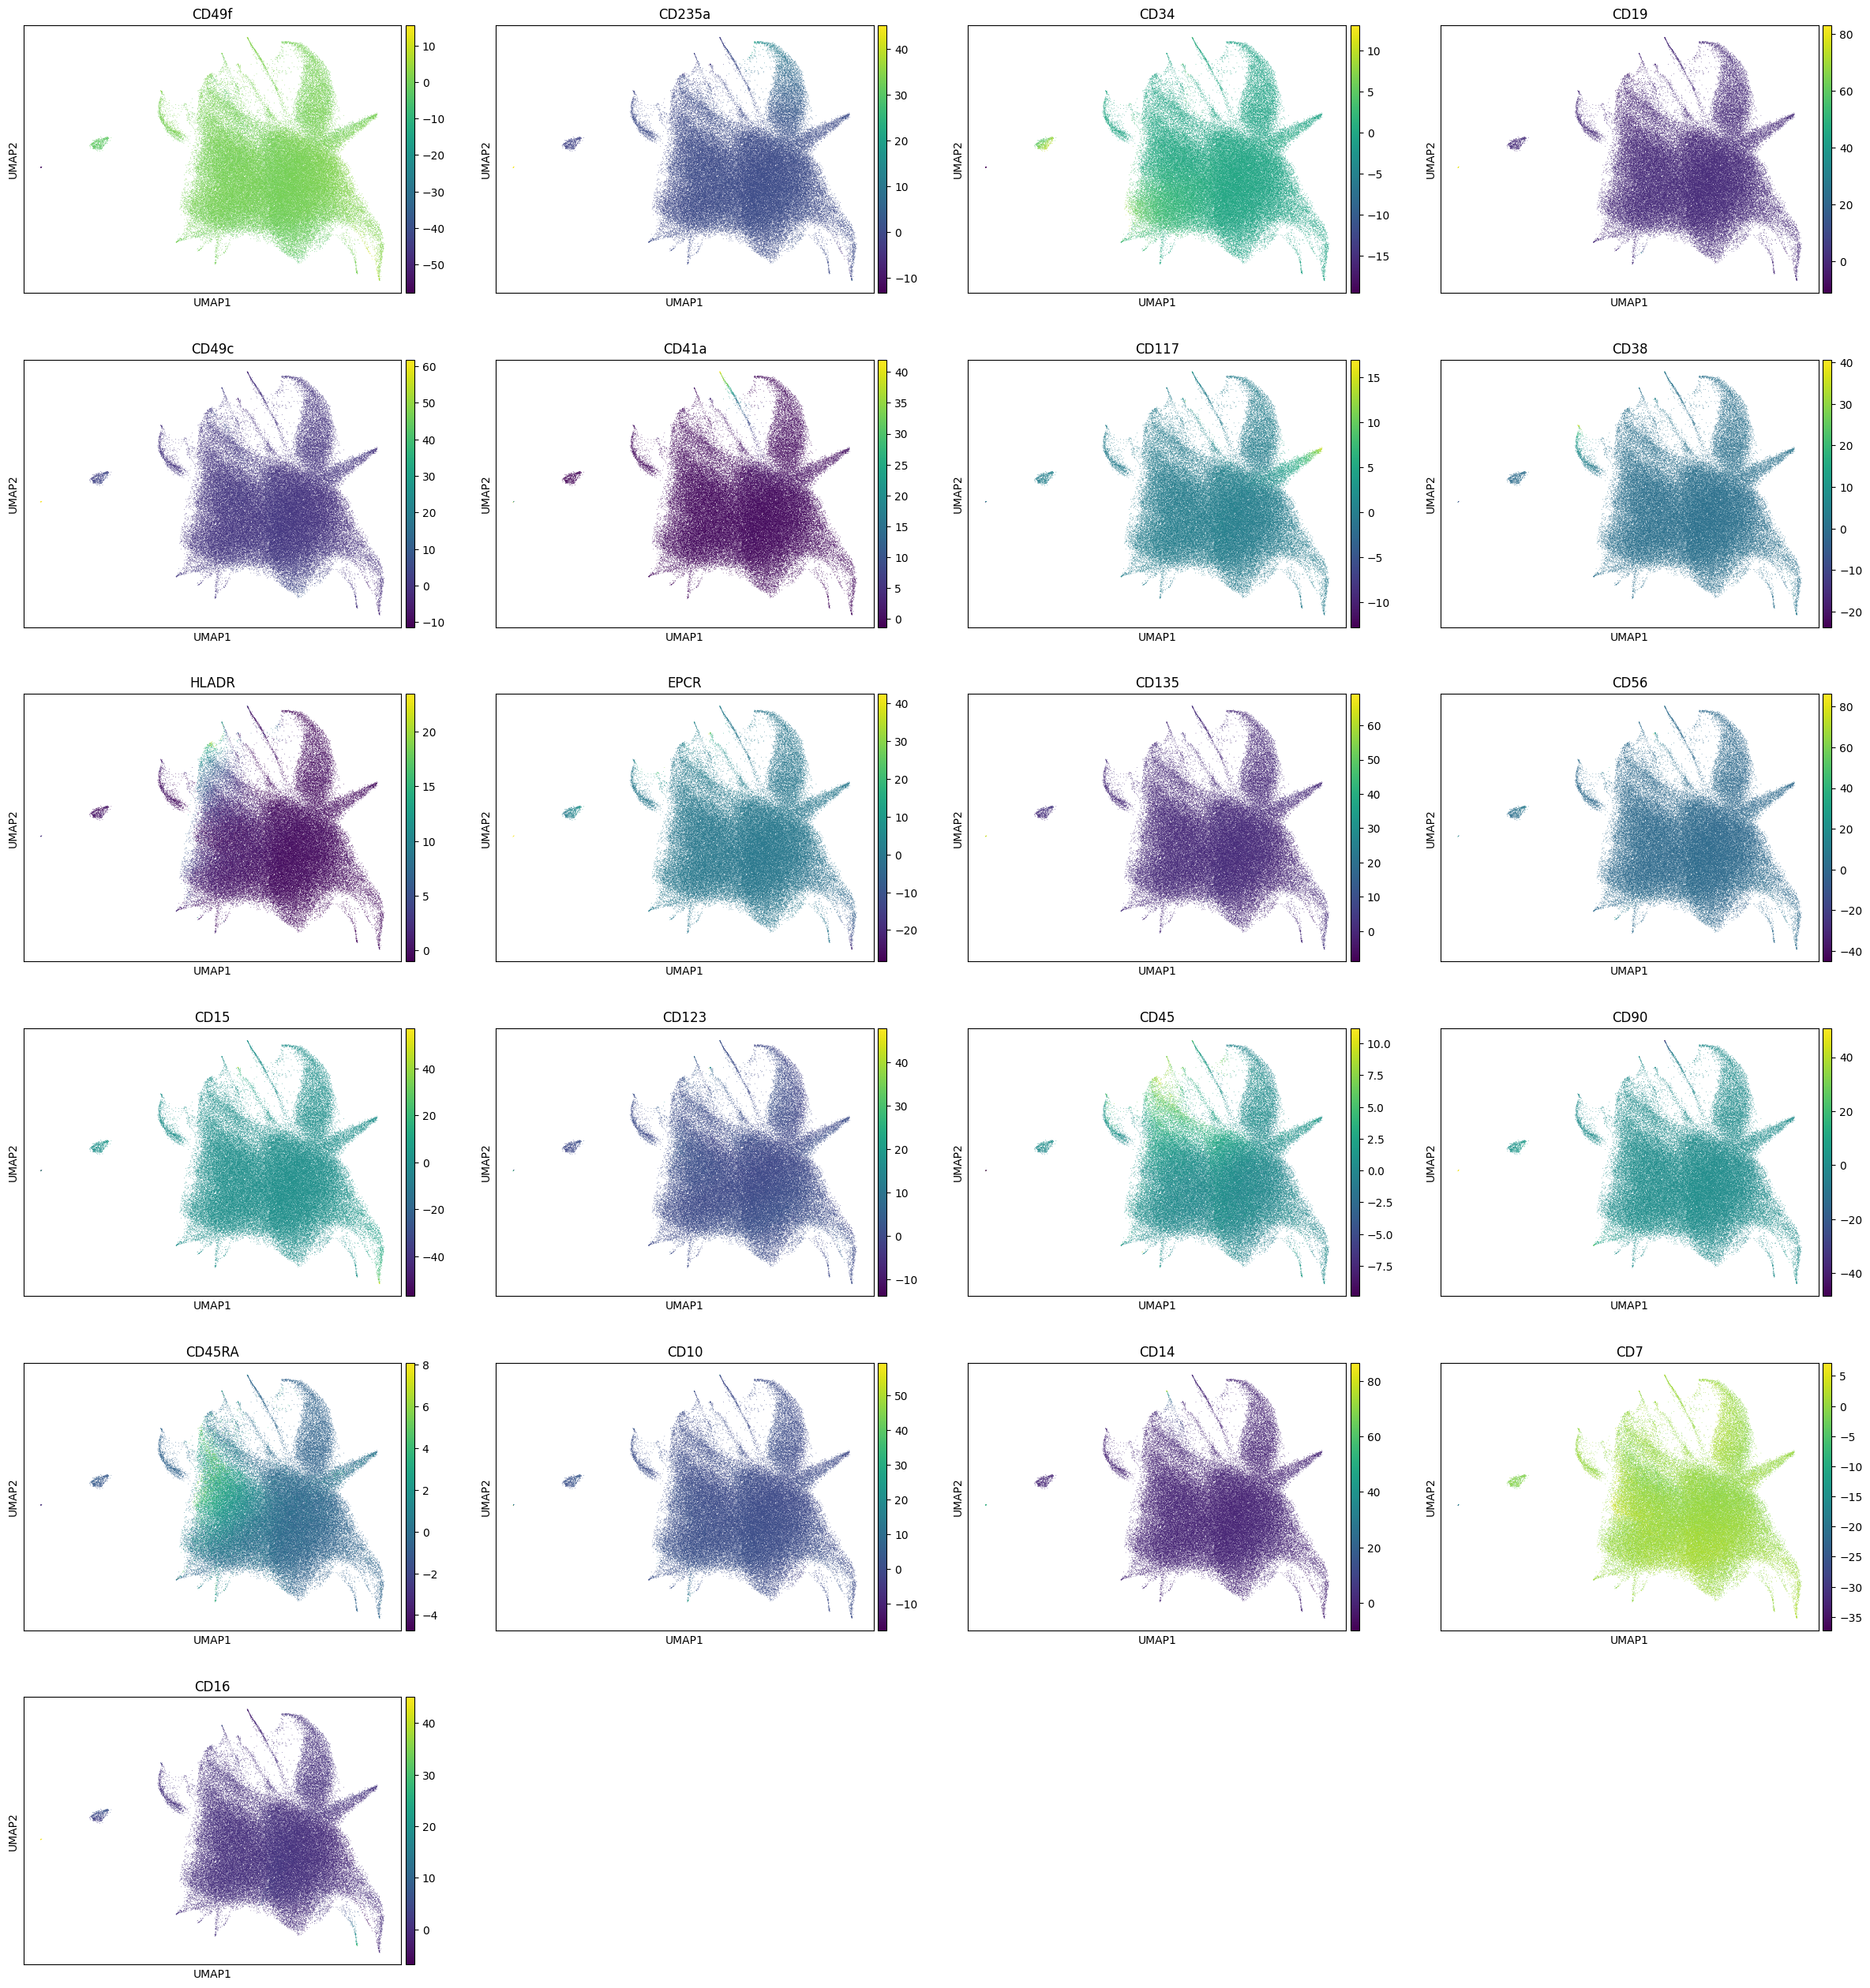

In [32]:
sc.pl.embedding(adatas_dict["HSCs"], "umap", color=adatas_dict["HSCs"].var_names)